# Decode TQEC circuits with qLDPC

[TQEC](https://github.com/tqec/tqec) compiles lattice-surgery block graphs into Stim circuits.
This notebook builds a logical CNOT, identifies its correlation-surface observables, and compares monolithic and sliding-window qLDPC decoders under depolarizing noise.

TQEC is an external notebook dependency rather than part of qLDPC's installed API.


## Setup

Install the dependencies once in the environment that will run the notebook:

```bash
python -m pip install qldpc matplotlib tqec
```


In [1]:
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
import tqec
import tqec.gallery
from tqec.simulation.plotting.inset import plot_observable_as_inset
from tqec.simulation.simulation import start_simulation_using_sinter

from qldpc import circuits, decoders

## Simulation and plotting helpers

These helpers are intentionally visible.
`get_simulation_data` compiles and samples one block graph at each requested code distance; `plot_stats` keeps the separate logical observables in separate figures.


In [2]:
def get_simulation_data(
    block_graph: tqec.BlockGraph,
    distances: Sequence[int],
    sinter_decoders: sinter.Decoder | Sequence[sinter.Decoder],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
) -> list[list[list[sinter.TaskStats]]]:
    """Simulate the given block graph at each code distance using start_simulation_using_sinter.

    Args:
        block_graph: The TQEC block graph describing the logical operation to simulate.
        distances: The surface code distances to simulate.
        sinter_decoders: A single decoder to use at all distances, or one decoder per distance.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stop sampling after this many errors have been seen.

    Returns:
        A list (over distances) of lists (over observables) of lists (over physical error rates)
            of sinter.TaskStats.
    """
    if isinstance(sinter_decoders, sinter.Decoder):
        custom_decoders = {str(dist): sinter_decoders for dist in distances}
    else:
        assert len(distances) == len(sinter_decoders)
        custom_decoders = {str(dist): decoder for dist, decoder in zip(distances, sinter_decoders)}
    correlation_surfaces = block_graph.find_correlation_surfaces()
    return [
        start_simulation_using_sinter(
            block_graph,
            [dist // 2],  # the "size" parameter for surface code patches in tqec
            error_rates,
            circuits.DepolarizingNoiseModel,
            manhattan_radius=2,
            observables=correlation_surfaces,
            max_shots=max_shots,
            max_errors=max_errors,
            decoders=[str(dist)],
            custom_decoders=custom_decoders,
            print_progress=False,
        )
        for dist in distances
    ]


def plot_stats(block_graph: tqec.BlockGraph, stats: list[list[list[sinter.TaskStats]]]) -> None:
    """Plot the logical error rate of each observable, with results grouped by code distance."""
    zx_graph = block_graph.to_zx_graph()
    correlation_surfaces = block_graph.find_correlation_surfaces()
    for observable, stat in zip(correlation_surfaces, zip(*stats)):
        _, ax = plt.subplots(figsize=(5, 4))
        sinter.plot_error_rate(
            ax=ax,
            stats=sum(stat, []),
            x_func=lambda s: s.json_metadata["p"],
            group_func=lambda s: s.json_metadata["d"],
        )
        plot_observable_as_inset(ax, zx_graph, observable)
        ax.grid(axis="both")
        ax.loglog()
        ax.set_xlabel("physical error rate")
        ax.set_ylabel("logical error rate")
        ax.legend(loc="best")
        ax.set_title("Logical CNOT observable")
        ax.figure.tight_layout()

## A logical CNOT and its observables

TQEC's gallery supplies a CNOT block graph.
`find_correlation_surfaces` returns a generating set of surfaces whose parities become Stim logical observables.
The interactive views below show the block graph and one such surface.


In [3]:
block_graph = tqec.gallery.cnot(tqec.Basis.Z)
block_graph.view_as_html()

In [4]:
correlation_surfaces = block_graph.find_correlation_surfaces()
block_graph.view_as_html(
    pop_faces_at_directions=("-Y",),
    show_correlation_surface=correlation_surfaces[0],
)

## Monolithic MWPM

The decoder sees the complete detector graph for each compiled circuit.
`decompose_errors=True` replaces a suggested correlated non-graphlike mechanism with graphlike components so MWPM can consume it.
That is an approximation to the original correlated model, not an exact treatment of every Y-type mechanism.


In [5]:
distances = [3, 5, 7]
decoder = decoders.SinterDecoder(
    with_MWPM=True,
    decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
)
mwpm_stats = get_simulation_data(block_graph, distances, decoder)

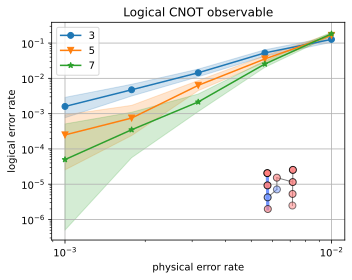

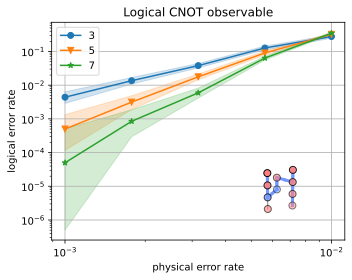

In [6]:
plot_stats(block_graph, mwpm_stats)
plt.show()

The two figures correspond to distinct CNOT observables, and each point is the per-shot failure probability for one compiled CNOT circuit.
Their finite-sample bars should be compared at equal code distance and physical error rate; smooth lines between the five sampled rates are only visual guides.


## Sliding-window decoding

For a long computation, decoding the entire history at once is not scalable.
The sliding-window decoder commits corrections a few rounds at a time while retaining an overlap with the next window.
Here the window size is the target distance and the stride is `distance // 2`.


In [7]:
distances = [3, 5, 7]
sliding_window_decoders = [
    decoders.SlidingWindowDecoder(
        dist,  # decoding window size
        dist // 2,  # commit window size
        with_MWPM=True,
        decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
    )
    for dist in distances
]
sliding_window_stats = get_simulation_data(block_graph, distances, sliding_window_decoders)

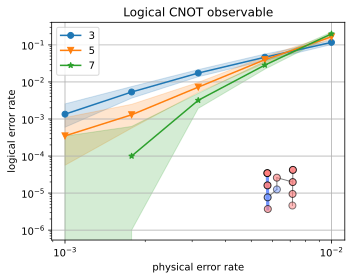

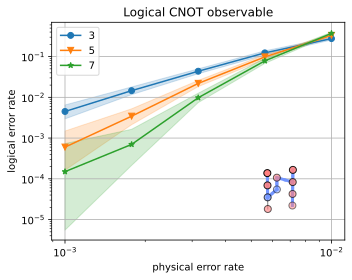

In [8]:
plot_stats(block_graph, sliding_window_stats)
plt.show()

This bounded comparison demonstrates the interface rather than a performance claim.
Window size, stride, detector-time coordinates, decoder approximation, and sample budget all affect the result.
